In [6]:
import requests
import pandas as pd
from datetime import timedelta, datetime

In [31]:
def load_carbon_intensity_data(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Load Carbon Intensity API data for any specified date range.
    Handles the API 31-day limit by fetching data in chunks.
    """

    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    if start >= end:
        raise ValueError("end_date must be after start_date")

    dfs = []
    current = start

    while current < end:
        next_date = min(current + timedelta(days=30), end)

        url = (
            f"https://api.carbonintensity.org.uk/intensity/"
            f"{current.strftime('%Y-%m-%d')}/{next_date.strftime('%Y-%m-%d')}"
        )

        response = requests.get(url, timeout=30)
        response.raise_for_status()

        try:
            payload = response.json()
        except ValueError:
            print(f"Warning: Carbon API returned non-JSON response for {current} - {next_date}")
            payload = {}

        data = payload.get("data", []) if isinstance(payload, dict) else []

        if data:
            dfs.append(pd.json_normalize(data))

        current = next_date

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [3]:
df = load_carbon_intensity_data('2023-01-01','2023-02-01')
df

,from,to,intensity.forecast,intensity.actual,intensity.index
0,2022-12-31T23:30Z,2023-01-01T00:00Z,75,65.0,low
1,2023-01-01T00:00Z,2023-01-01T00:30Z,73,72.0,low
2,2023-01-01T00:30Z,2023-01-01T01:00Z,63,80.0,low
3,2023-01-01T01:00Z,2023-01-01T01:30Z,71,72.0,low
4,2023-01-01T01:30Z,2023-01-01T02:00Z,76,65.0,low
...,...,...,...,...,...
1485,2023-01-31T21:30Z,2023-01-31T22:00Z,127,96.0,low
1486,2023-01-31T22:00Z,2023-01-31T22:30Z,104,95.0,low
1487,2023-01-31T22:30Z,2023-01-31T23:00Z,84,81.0,low
1488,2023-01-31T23:00Z,2023-01-31T23:30Z,82,74.0,low


In [32]:
def preprocess_carbon_intensity_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and preprocess Carbon Intensity API dataframe.
    """

    if df.empty:
        return pd.DataFrame(columns=["timestamp", "carbon_intensity_gCO2_kWh"])

    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["from"], utc=True).dt.tz_convert(None)
    df = df.rename(columns={
        "intensity.actual": "carbon_intensity_gCO2_kWh",  # ← rename directly, skip intermediate
        "intensity.forecast": "forecast"
    })
    df["carbon_intensity_gCO2_kWh"] = pd.to_numeric(df["carbon_intensity_gCO2_kWh"], errors='coerce')
    df = df[["timestamp", "carbon_intensity_gCO2_kWh"]]

    df = (
        df
        .sort_values("timestamp")
        .drop_duplicates(subset="timestamp")
        .reset_index(drop=True)
    )

    return df

In [58]:
def preprocess_carbon_intensity_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and preprocess Carbon Intensity API dataframe.
    """

    if df.empty:
        return pd.DataFrame(columns=["timestamp", "carbon_intensity_gCO2_kWh"])

    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["from"], utc=True).dt.tz_convert(None)
    df = df.rename(columns={
        "intensity.actual": "actual",
        "intensity.forecast": "forecast"
    })
    df["carbon_intensity_gCO2_kWh"] = pd.to_numeric(df["actual"], errors='coerce')
    df["carbon_intensity_gCO2_kWh"] = df["carbon_intensity_gCO2_kWh"].fillna(
        pd.to_numeric(df["forecast"], errors='coerce')
    )
    df = df[["timestamp", "carbon_intensity_gCO2_kWh"]]

    df = (
        df
        .sort_values("timestamp")
        .drop_duplicates(subset="timestamp")
        .reset_index(drop=True)
    )

    return df


In [59]:
carbon_df = load_carbon_intensity_data('2017-09-12', '2017-12-30')
carbon_df = preprocess_carbon_intensity_data(carbon_df)
print(carbon_df.columns.tolist())
print(carbon_df.dtypes)
print(carbon_df.head(-10))

['timestamp', 'carbon_intensity_gCO2_kWh']
timestamp                    datetime64[ns]
carbon_intensity_gCO2_kWh             int64
dtype: object
               timestamp  carbon_intensity_gCO2_kWh
0    2017-09-11 23:30:00                        144
1    2017-09-12 00:00:00                        142
2    2017-09-12 00:30:00                        140
3    2017-09-12 01:00:00                        139
4    2017-09-12 01:30:00                        137
...                  ...                        ...
5218 2017-12-29 16:30:00                        289
5219 2017-12-29 17:00:00                        285
5220 2017-12-29 17:30:00                        286
5221 2017-12-29 18:00:00                        278
5222 2017-12-29 18:30:00                        282

[5223 rows x 2 columns]


In [51]:
def fetch_exelon(start_date, end_date):
    """
    fetch data within specifite dates from Exelon AGBT API and returns it as a pandas dataframe
    """
    url = "https://data.elexon.co.uk/bmrs/api/v1/generation/actual/per-type"

    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")

    dfs = []

    while start <= end:

        chunk_end = min(start + timedelta(days=6), end)

        params = {
            "from": start.strftime("%Y-%m-%d"),
            "to": chunk_end.strftime("%Y-%m-%d"),
            "settlementPeriodFrom": 1,
            "settlementPeriodTo": 50,
            "format": "json"
        }

        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()

        data = response.json().get("data", [])

        if data:
            df_raw = pd.DataFrame(data)
            df_exploded = df_raw.explode('data').reset_index(drop=True)
            df_normalized = pd.json_normalize(df_exploded['data'])
            df_normalized['startTime'] = df_exploded['startTime'].values
            dfs.append(df_normalized)

        start = chunk_end + timedelta(days=1)

    if not dfs:
        return pd.DataFrame(columns=["startTime", "psrType", "quantity"])

    return pd.concat(dfs, ignore_index=True)

In [52]:
exelon_df = fetch_exelon('2017-09-01', '2026-03-12')
exelon_df

,businessType,psrType,quantity,startTime
0,Production,Biomass,0.000,2017-08-31T23:00:00Z
1,Production,Fossil Gas,9448.000,2017-08-31T23:00:00Z
2,Production,Fossil Hard coal,1777.000,2017-08-31T23:00:00Z
3,Production,Fossil Oil,0.000,2017-08-31T23:00:00Z
4,Production,Hydro Pumped Storage,0.000,2017-08-31T23:00:00Z
...,...,...,...,...
1593004,Production,Nuclear,3205.000,2026-03-12T12:00:00Z
1593005,Production,Other,703.000,2026-03-12T12:00:00Z
1593006,Solar generation,Solar,2610.000,2026-03-12T12:00:00Z
1593007,Wind generation,Wind Offshore,11531.621,2026-03-12T12:00:00Z


In [25]:
def exelon_preproc(df):
    """
    preprocessing exelon dataframe:
    convert StartTime column from object into datetime, pivot PsrType (fuel type) column
    into their own columns with their individual generation quantities,
    """
    df['startTime'] = pd.to_datetime(df['startTime']).dt.tz_convert(None)
    df_pivot = df.pivot_table(
        index='startTime',
        columns='psrType',
        values='quantity',
        aggfunc='sum'
    )

    df_pivot['TotalOutput-MW'] = df_pivot.sum(axis=1)

    return df_pivot

In [53]:
# exelon_df = fetch_exelon('2017-09-12', '2026-03-12')
exelon_df = exelon_preproc(exelon_df)
print(exelon_df.columns.tolist())
print(exelon_df.dtypes)
print(exelon_df.head())

['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar', 'Wind Offshore', 'Wind Onshore', 'TotalOutput-MW']
psrType
Biomass                            float64
Fossil Gas                         float64
Fossil Hard coal                   float64
Fossil Oil                         float64
Hydro Pumped Storage               float64
Hydro Run-of-river and poundage    float64
Nuclear                            float64
Other                              float64
Solar                              float64
Wind Offshore                      float64
Wind Onshore                       float64
TotalOutput-MW                     float64
dtype: object
psrType              Biomass  Fossil Gas  Fossil Hard coal  Fossil Oil  \
startTime                                                                
2017-08-31 23:00:00      0.0      9448.0            1777.0         0.0   
2017-08-31 23:30:00      0.0      8828.0 

array([[<Axes: title={'center': 'Biomass'}>,
        <Axes: title={'center': 'Fossil Gas'}>,
        <Axes: title={'center': 'Fossil Hard coal'}>],
       [<Axes: title={'center': 'Fossil Oil'}>,
        <Axes: title={'center': 'Hydro Pumped Storage'}>,
        <Axes: title={'center': 'Hydro Run-of-river and poundage'}>],
       [<Axes: title={'center': 'Nuclear'}>,
        <Axes: title={'center': 'Other'}>,
        <Axes: title={'center': 'Solar'}>],
       [<Axes: title={'center': 'Wind Offshore'}>,
        <Axes: title={'center': 'Wind Onshore'}>,
        <Axes: title={'center': 'TotalOutput-MW'}>]], dtype=object)

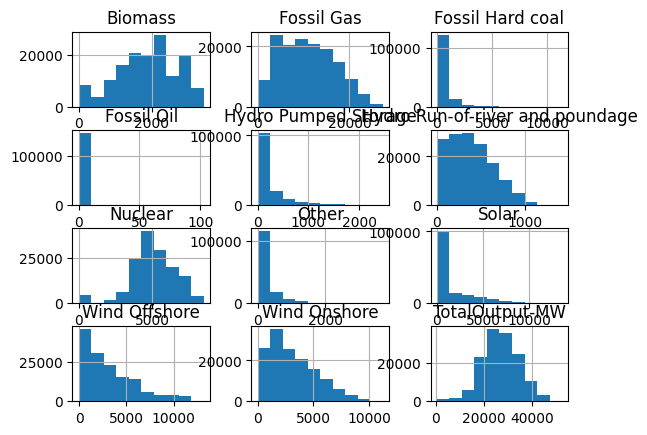

In [54]:
exelon_df.hist()

In [55]:
exelon_df.apply(lambda x: x==0).sum()

psrType
Biomass                              7456
Fossil Gas                           4505
Fossil Hard coal                    78031
Fossil Oil                         144810
Hydro Pumped Storage                65319
Hydro Run-of-river and poundage      4505
Nuclear                              4505
Other                                4718
Solar                               62295
Wind Offshore                          73
Wind Onshore                           65
TotalOutput-MW                          0
dtype: int64

In [56]:
# exelon_df = fetch_exelon('2017-09-12', '2026-03-12')
print(exelon_df[exelon_df['quantity'] == 0].groupby('psrType').count())

KeyError: 'quantity'

In [57]:
# exelon_df = fetch_exelon('2023-01-01', '2023-02-01')
zero_times = exelon_df[(exelon_df['quantity'] == 0) & (exelon_df['psrType'] == 'Nuclear')]['startTime']
print(zero_times.shape())

KeyError: 'quantity'

In [29]:
zero_times = exelon_df[(exelon_df['quantity'] == 0) & (exelon_df['psrType'] == 'Nuclear')]['startTime']
print(zero_times.tail(10))
print(f"Total zero periods: {len(zero_times)}")
print(f"Last zero: {zero_times.max()}")
print(f"First non-zero: {exelon_df[(exelon_df['quantity'] != 0) & (exelon_df['psrType'] == 'Nuclear')]['startTime'].min()}")

5924    2023-01-12T06:00:00Z
5935    2023-01-12T06:30:00Z
5946    2023-01-12T07:00:00Z
5957    2023-01-12T07:30:00Z
5968    2023-01-12T08:00:00Z
5979    2023-01-12T08:30:00Z
5990    2023-01-12T09:00:00Z
6001    2023-01-12T09:30:00Z
6012    2023-01-12T10:00:00Z
6023    2023-01-12T10:30:00Z
Name: startTime, dtype: object
Total zero periods: 548
Last zero: 2023-01-12T10:30:00Z
First non-zero: 2023-01-12T11:00:00Z


what to do about data gaps in production like 2023:
impute?
delete - if so delete all rows? or just production rows?
currently showing as zero rather than as nulls
maybe go find where nuclear = zero - turn all production to NaN MASK/IMPUTE


In [30]:
def fetch_weather(start_date, end_date, latitude=51.5, longitude=-0.1):
    '''fetch api data from open-meteo archive,
    returns selected parameters hourly for London (based on long and lat).
    Dates in string format. See weather_data_notes.txt for information on selected params.'''

    url = 'https://archive-api.open-meteo.com/v1/archive'

    selected_params = {
        'latitude': latitude,
        'longitude': longitude,
        'start_date': start_date,
        'end_date': end_date,
        'timezone': 'UTC',
        'hourly': [
            'temperature_2m',
            'wind_speed_100m',
            'wind_gusts_10m',
            'cloud_cover',
            'shortwave_radiation',
            'direct_radiation',
            'diffuse_radiation',
            'pressure_msl',
            'snowfall',
            'rain',
            'precipitation'
        ]
    }

    response = requests.get(url, params=selected_params, timeout=30)
    response.raise_for_status()

    data = response.json()

    if "hourly" not in data:
        raise ValueError(f"Unexpected API response:{data}")

    df = pd.DataFrame(data["hourly"])

    return df

make a predictive energy thing that can beat the prediction of the grid